In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PATH12_grid= '/glade/campaign/cgd/oce/people/rita/JRA55raw/landsea_mask/'
filename12_grid = 'JRA55_grid_file.nc'
mask_12 = 1 - xr.open_dataset(PATH12_grid + filename12_grid, engine="netcdf4")['tmask'].rename({"i": "longitude", "j": "latitude"})
area_12 =  xr.open_dataset(PATH12_grid + filename12_grid, engine="netcdf4")['tarea'].rename({"i": "longitude", "j": "latitude"})

PATH125_grid= '/glade/campaign/cgd/oce/people/rita/JRA55raw_125/landsea_mask/'
filename125_grid = 'JRA55raw_125_landsea_mask_and_areas.nc'
mask_125 = 1 - xr.open_dataset(PATH125_grid + filename125_grid, engine="netcdf4")['mask'].rename({"lon": "longitude", "lat": "latitude"})



PATH3_grid = '/glade/derecho/scratch/mmarkina/archive/a.e30.A_ERA5.TL319_t232.daily_SST_ERA5_2000_2009/cpl/hist/'
filename3_grid = 'a.e30.A_ERA5.TL319_t232.daily_SST_ERA5_2000_2009.cpl.hi.2010-01-01-00000.nc'
mask_3 = xr.open_dataset(PATH3_grid + filename3_grid, engine="netcdf4")['ocnImp_So_omask'].isel(time=0, drop = True).rename({"ocnImp_ny": "latitude", "ocnImp_nx": "longitude"})
R2 = 6371e3**2 # since output area is in radians
area_3 = R2*(xr.open_dataset(PATH3_grid + filename3_grid, engine="netcdf4")['MED_ocn_area'].isel(time=0, drop = True).rename({"MED_ocn_ny": "latitude", "MED_ocn_nx": "longitude"}))

In [3]:
PATH1 = '/glade/campaign/cgd/oce/people/rita/JRA55raw/'
PATH125 = '/glade/campaign/cgd/oce/people/rita/JRA55raw_125/'
PATH2 = '/glade/campaign/cgd/oce/people/rita/JRA55do/'
PATH3 = '/glade/campaign/cgd/oce/people/rita/ERA5/'


time_1 = pd.date_range(start="1958-01-01", end="2023-01-01", freq="YS")
time_125 = pd.date_range(start="1958-01-01", end="2013-01-01", freq="YS")
time_2 = pd.date_range(start="1958-01-01", end="2020-01-01", freq="YS")
time_3 = pd.date_range(start="1940-01-01", end="2020-01-01", freq="YS")

filename1 = '_yearly_mean_1958_2023.nc'
filename125 = '_yearly_mean_1958_2013.nc'
filename2 = '_yearly_mean_1958_2020.nc'
filename3 = '_yearly_mean_1940_2020.nc'


filename1_temp = '_yearly_mean_1958_2019.nc'
filename2_temp = '_yearly_mean_1958_2020.nc'
filename3_temp = '_yearly_mean_1940_2020.nc'

filename1_prec = '_yearly_mean_1958_2020.nc'
filename2_prec = '_yearly_mean_1958_2020.nc'
filename3_prec = '_yearly_mean_1940_2020.nc'

swdn1 = xr.open_dataset(PATH1 + 'swdn_yearly_means/swdn' + filename1, engine="netcdf4")
lwdn1 = xr.open_dataset(PATH1 + 'lwdn_yearly_means/lwdn' + filename1, engine="netcdf4")
temp1 = xr.open_dataset(PATH1 + 't_10_yearly_means/t_10' + filename1_temp, engine="netcdf4")
prec1 = xr.open_dataset(PATH1 + 'prec_yearly_means/prec' + filename1_prec, engine="netcdf4")

area_12['latitude'] = prec1['latitude']
area_12['longitude'] = prec1['longitude']
precip_area_1 = prec1.prec * area_12

swdn125 = xr.open_dataset(PATH125 + 'swdn_yearly_means/swdn' + filename125, engine="netcdf4").rename({"lon": "longitude", "lat": "latitude"})
lwdn125 = xr.open_dataset(PATH125 + 'lwdn_yearly_means/lwdn' + filename125, engine="netcdf4").rename({"lon": "longitude", "lat": "latitude"})
# temp125 = xr.open_dataset(PATH125 + 't_10_yearly_means/t_10' + filename1_temp, engine="netcdf4")
# prec125 = xr.open_dataset(PATH125 + 'prec_yearly_means/prec' + filename1_prec, engine="netcdf4")

swdn2 = xr.open_dataset(PATH2 + 'swdn_yearly_means/swdn' + filename2, engine="netcdf4")
lwdn2 = xr.open_dataset(PATH2 + 'lwdn_yearly_means/lwdn' + filename2, engine="netcdf4")
temp2 = xr.open_dataset(PATH2 + 't_10_yearly_means/t_10' + filename2_temp, engine="netcdf4")
prec2 = xr.open_dataset(PATH2 + 'prec_yearly_means/prec' + filename2_prec, engine="netcdf4")

area_12['latitude'] = prec2['latitude']
area_12['longitude'] = prec2['longitude']
precip_area_2 = prec2.prec * area_12

swdn3 = xr.open_dataset(PATH3 + 'swdn_yearly_means/swdn' + filename3, engine="netcdf4")
lwdn3 = xr.open_dataset(PATH3 + 'lwdn_yearly_means/lwdn' + filename3, engine="netcdf4")
temp3 = xr.open_dataset(PATH3 + 't_10_yearly_means/t_10' + filename3_temp, engine="netcdf4")
prec3 = xr.open_dataset(PATH3 + 'prec_yearly_means/prec' + filename3_prec, engine="netcdf4")

area_3['latitude'] = prec3['latitude']
area_3['longitude'] = prec3['longitude']

precip_area_3 = prec3.prec * area_3

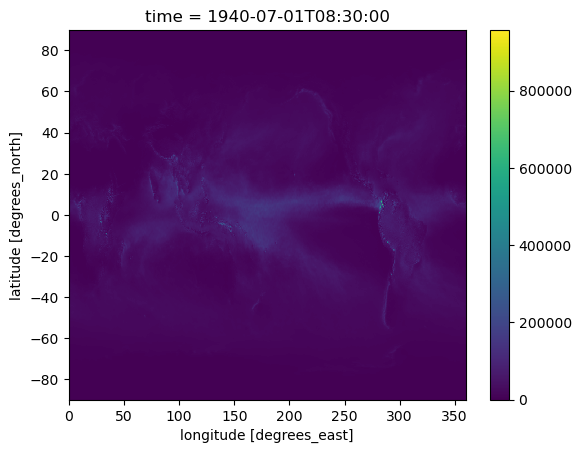

In [4]:
precip_area_3.isel(time=0).plot()

In [5]:
mask_12['latitude'] = np.flipud(swdn1['latitude'])
mask_12['longitude'] = swdn1['longitude']

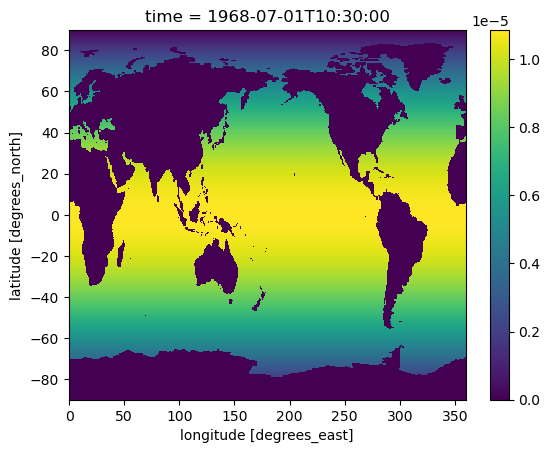

In [6]:
weights = np.cos(np.deg2rad(swdn1['latitude']))
weights = weights / weights.sum()  # Normalize so they sum to 1
weights = weights.broadcast_like(swdn1['swdn'])  # Ensure shape matches the data variable

swdn_means1 = swdn1.swdn.weighted(weights).mean(dim=["latitude", "longitude"])
lwdn_means1 = lwdn1.lwdn.weighted(weights).mean(dim=["latitude", "longitude"])

weights = np.cos(np.deg2rad(temp1['latitude']))
weights = weights / weights.sum()  # Normalize so they sum to 1
weights = weights.broadcast_like(temp1['t_10'])  # Ensure shape matches the data variable
temp_means1 = temp1.t_10.weighted(weights).mean(dim=["latitude", "longitude"])


# weights = np.cos(np.deg2rad(precip_area_1['latitude']))
# weights = weights / weights.sum()  # Normalize so they sum to 1
# weights = weights.broadcast_like(precip_area_1)  # Ensure shape matches the data variable
prec_means1 = precip_area_1.sum(dim=["latitude", "longitude"])

weights_ocean = np.cos(np.deg2rad(swdn1['latitude']))*mask_12
weights_ocean = weights_ocean / weights_ocean.sum()  # Normalize so they sum to 1
weights_ocean = weights_ocean.broadcast_like(swdn1['swdn'])  # Ensure shape matches the data variable

swdn_ocean_means1 = swdn1.swdn.weighted(weights_ocean).mean(dim=["latitude", "longitude"])
lwdn_ocean_means1 = lwdn1.lwdn.weighted(weights_ocean).mean(dim=["latitude", "longitude"])

weights_ocean = np.cos(np.deg2rad(temp1['latitude']))*mask_12
weights_ocean = weights_ocean / weights_ocean.sum()  # Normalize so they sum to 1
weights_ocean = weights_ocean.broadcast_like(temp1['t_10'])  # Ensure shape matches the data variable
temp_ocean_means1 = temp1.t_10.weighted(weights_ocean).mean(dim=["latitude", "longitude"])


# weights_ocean = np.cos(np.deg2rad(precip_area_1['latitude']))*mask_12
# weights_ocean = weights_ocean / weights_ocean.sum()  # Normalize so they sum to 1
# weights_ocean = weights_ocean.broadcast_like(precip_area_1)  # Ensure shape matches the data variable
prec_ocean_means1 = (precip_area_1 * mask_12).sum(dim=["latitude", "longitude"])

swdn_means1['time'] = time_1[0: len(swdn_means1['time'])]
lwdn_means1['time'] = time_1[0: len(lwdn_means1['time'])]
temp_means1['time'] = time_1[0: len(temp_means1['time'])]
prec_means1['time'] = time_1[0: len(prec_means1['time'])]
swdn_ocean_means1['time'] = time_1[0: len(swdn_means1['time'])]
lwdn_ocean_means1['time'] = time_1[0: len(lwdn_means1['time'])]
temp_ocean_means1['time'] = time_1[0: len(temp_means1['time'])]
prec_ocean_means1['time'] = time_1[0: len(prec_means1['time'])]

# weights.isel(time=0).plot()
weights_ocean.isel(time=10).plot()


# del weights, weights_ocean

In [7]:
# weights = np.cos(np.deg2rad(swdn125['latitude']))

# # Expand dimensions to match the dataset
# weights = weights / weights.sum()  # Normalize so they sum to 1
# weights = weights.broadcast_like(swdn125['swdn'])  # Ensure shape matches the data variable

# swdn_means125 = swdn125.swdn.weighted(weights).mean(dim=["latitude", "longitude"])
# lwdn_means125 = lwdn125.lwdn.weighted(weights).mean(dim=["latitude", "longitude"])


# weights_ocean = np.cos(np.deg2rad(swdn125['latitude']))*mask_125

# # Expand dimensions to match the dataset
# weights_ocean = weights_ocean / weights_ocean.sum()  # Normalize so they sum to 1
# weights_ocean = weights_ocean.broadcast_like(swdn125['swdn'])  # Ensure shape matches the data variable

# swdn_ocean_means125 = swdn125.swdn.weighted(weights_ocean).mean(dim=["latitude", "longitude"])
# lwdn_ocean_means125 = lwdn125.lwdn.weighted(weights_ocean).mean(dim=["latitude", "longitude"])

# swdn_means125['time'] = time_125
# lwdn_means125['time'] = time_125
# swdn_ocean_means125['time'] = time_125
# lwdn_ocean_means125['time'] = time_125


# weights_ocean.isel(time=0).plot()

# del weights, weights_ocean

In [8]:
# swdn_ocean_means125.plot()

In [9]:
mask_12['latitude'] = swdn2['latitude']
mask_12['longitude'] = swdn2['longitude']

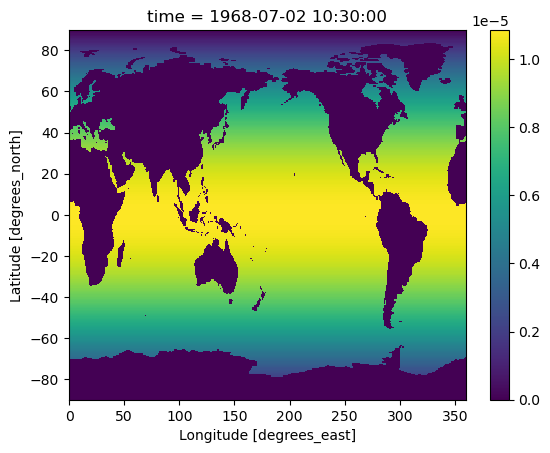

In [10]:
weights = np.cos(np.deg2rad(swdn2['latitude']))
weights = weights / weights.sum()  # Normalize so they sum to 1
weights = weights.broadcast_like(swdn2['swdn'])  # Ensure shape matches the data variable

swdn_means2 = swdn2.swdn.weighted(weights).mean(dim=["latitude", "longitude"])
lwdn_means2 = lwdn2.lwdn.weighted(weights).mean(dim=["latitude", "longitude"])

weights = np.cos(np.deg2rad(temp2['latitude']))
weights = weights / weights.sum()  # Normalize so they sum to 1
weights = weights.broadcast_like(temp2['t_10'])  # Ensure shape matches the data variable
temp_means2 = temp2.t_10.weighted(weights).mean(dim=["latitude", "longitude"])

# weights = np.cos(np.deg2rad(precip_area_2['latitude']))
# weights = weights / weights.sum()  # Normalize so they sum to 1
# weights = weights.broadcast_like(precip_area_2)  # Ensure shape matches the data variable
prec_means2 = precip_area_2.sum(dim=["latitude", "longitude"])

weights_ocean = np.cos(np.deg2rad(swdn2['latitude']))*mask_12
weights_ocean = weights_ocean / weights_ocean.sum()  # Normalize so they sum to 1
weights_ocean = weights_ocean.broadcast_like(swdn2['swdn'])  # Ensure shape matches the data variable

swdn_ocean_means2 = swdn2.swdn.weighted(weights_ocean).mean(dim=["latitude", "longitude"])
lwdn_ocean_means2 = lwdn2.lwdn.weighted(weights_ocean).mean(dim=["latitude", "longitude"])

weights_ocean = np.cos(np.deg2rad(temp2['latitude']))*mask_12
weights_ocean = weights_ocean / weights_ocean.sum()  # Normalize so they sum to 1
weights_ocean = weights_ocean.broadcast_like(temp2['t_10'])  # Ensure shape matches the data variable
temp_ocean_means2 = temp2.t_10.weighted(weights_ocean).mean(dim=["latitude", "longitude"])


# weights_ocean = np.cos(np.deg2rad(precip_area_2['latitude']))*mask_12
# weights_ocean = weights_ocean / weights_ocean.sum()  # Normalize so they sum to 1
# weights_ocean = weights_ocean.broadcast_like(precip_area_2)  # Ensure shape matches the data variable
prec_ocean_means2 = (precip_area_2*mask_12).sum(dim=["latitude", "longitude"])

swdn_means2['time'] = time_2[0: len(swdn_means2['time'])]
lwdn_means2['time'] = time_2[0: len(lwdn_means2['time'])]
temp_means2['time'] = time_2[0: len(temp_means2['time'])]
prec_means2['time'] = time_2[0: len(prec_means2['time'])]
swdn_ocean_means2['time'] = time_2[0: len(swdn_means2['time'])]
lwdn_ocean_means2['time'] = time_2[0: len(lwdn_means2['time'])]
temp_ocean_means2['time'] = time_2[0: len(temp_means2['time'])]
prec_ocean_means2['time'] = time_2[0: len(prec_means2['time'])]

# weights.isel(time=0).plot()
weights_ocean.isel(time=10).plot()


# del weights, weights_ocean

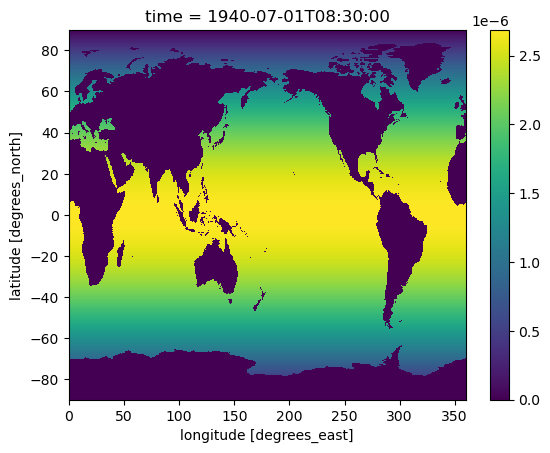

In [11]:
mask_3['latitude'] = swdn3['latitude']
mask_3['longitude'] = swdn3['longitude']

weights = np.cos(np.deg2rad(swdn3['latitude']))
weights = weights / weights.sum()  # Normalize so they sum to 1
weights = weights.broadcast_like(swdn3['swdn'])  # Ensure shape matches the data variable

swdn_means3 = swdn3.swdn.weighted(weights).mean(dim=["latitude", "longitude"])
lwdn_means3 = lwdn3.lwdn.weighted(weights).mean(dim=["latitude", "longitude"])

weights = np.cos(np.deg2rad(temp3['latitude']))
weights = weights / weights.sum()  # Normalize so they sum to 1
weights = weights.broadcast_like(temp3['t_10'])  # Ensure shape matches the data variable
temp_means3 = temp3.t_10.weighted(weights).mean(dim=["latitude", "longitude"])


# weights = np.cos(np.deg2rad(precip_area_3['latitude']))
# weights = weights / weights.sum()  # Normalize so they sum to 1
# weights = weights.broadcast_like(precip_area_3)  # Ensure shape matches the data variable
prec_means3 = precip_area_3.sum(dim=["latitude", "longitude"])

weights_ocean = np.cos(np.deg2rad(swdn3['latitude']))*mask_3
weights_ocean = weights_ocean / weights_ocean.sum()  # Normalize so they sum to 1
weights_ocean = weights_ocean.broadcast_like(swdn3['swdn'])  # Ensure shape matches the data variable

swdn_ocean_means3 = swdn3.swdn.weighted(weights_ocean).mean(dim=["latitude", "longitude"])
lwdn_ocean_means3 = lwdn3.lwdn.weighted(weights_ocean).mean(dim=["latitude", "longitude"])

weights_ocean = np.cos(np.deg2rad(temp3['latitude']))*mask_3
weights_ocean = weights_ocean / weights_ocean.sum()  # Normalize so they sum to 1
weights_ocean = weights_ocean.broadcast_like(temp3['t_10'])  # Ensure shape matches the data variable
temp_ocean_means3 = temp3.t_10.weighted(weights_ocean).mean(dim=["latitude", "longitude"])


# weights_ocean = np.cos(np.deg2rad(precip_area_3['latitude']))*mask_3
# weights_ocean = weights_ocean / weights_ocean.sum()  # Normalize so they sum to 1
# weights_ocean = weights_ocean.broadcast_like(precip_area_3)  # Ensure shape matches the data variable
prec_ocean_means3 = (precip_area_3 * mask_3).sum(dim=["latitude", "longitude"])

swdn_means3['time'] = time_3[0: len(swdn_means3['time'])]
lwdn_means3['time'] = time_3[0: len(lwdn_means3['time'])]
temp_means3['time'] = time_3[0: len(temp_means3['time'])]
prec_means3['time'] = time_3[0: len(prec_means3['time'])]
swdn_ocean_means3['time'] = time_3[0: len(swdn_means3['time'])]
lwdn_ocean_means3['time'] = time_3[0: len(lwdn_means3['time'])]
temp_ocean_means3['time'] = time_3[0: len(temp_means3['time'])]
prec_ocean_means3['time'] = time_3[0: len(prec_means3['time'])]


weights_ocean.isel(time=0).plot()

del weights, weights_ocean

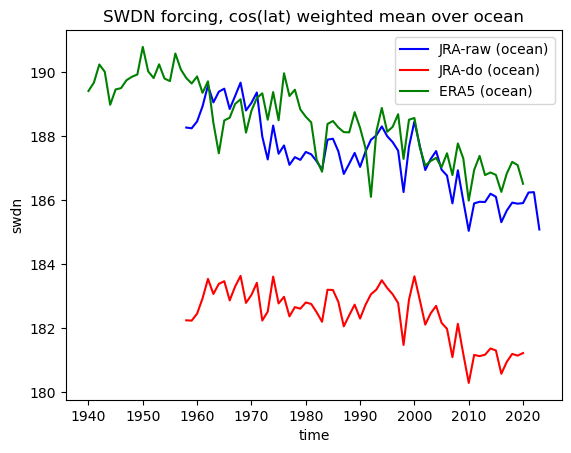

In [12]:
swdn_ocean_means1.plot(c = 'b', label = 'JRA-raw (ocean)')
# swdn_ocean_means125.plot(c = 'b', linestyle = 'dashed', label = 'JRA-raw (1.25º) (ocean)')
swdn_ocean_means2.plot(c = 'r', label = 'JRA-do (ocean)')
swdn_ocean_means3.plot(c = 'g', label = 'ERA5 (ocean)')
plt.title('SWDN forcing, cos(lat) weighted mean over ocean')
plt.legend()

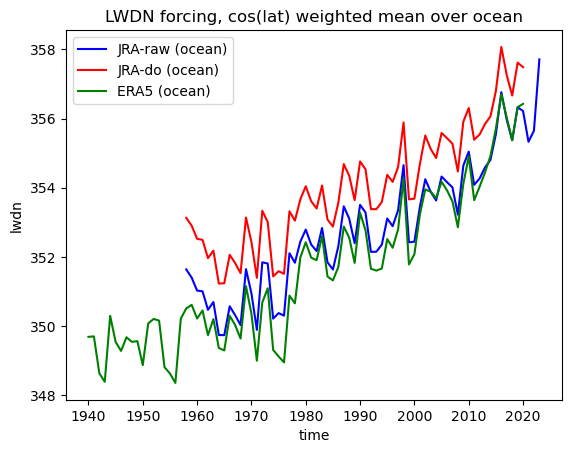

In [13]:
lwdn_ocean_means1.plot(c = 'b', label = 'JRA-raw (ocean)')
# lwdn_ocean_means125.plot(c = 'b', linestyle = 'dashed', label = 'JRA-raw (1.25º) (ocean)')
lwdn_ocean_means2.plot(c = 'r', label = 'JRA-do (ocean)')
lwdn_ocean_means3.plot(c = 'g', label = 'ERA5 (ocean)')
plt.title('LWDN forcing, cos(lat) weighted mean over ocean')
plt.legend()

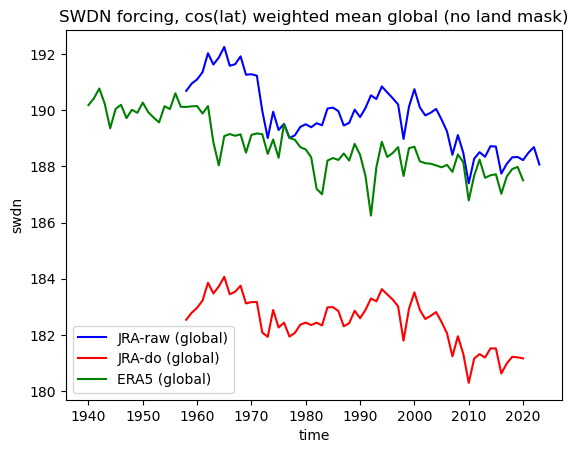

In [14]:
swdn_means1.plot(c = 'b', label = 'JRA-raw (global)')
# swdn_means125.plot(c = 'b', linestyle = 'dashed', label = 'JRA-raw (1.25º) (global)')
swdn_means2.plot(c = 'r',  label = 'JRA-do (global)')
swdn_means3.plot(c = 'g', label = 'ERA5 (global)')
plt.title('SWDN forcing, cos(lat) weighted mean global (no land mask)')
plt.legend()

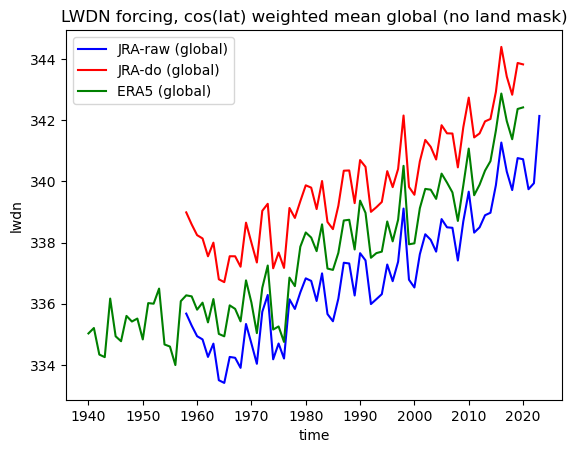

In [15]:
lwdn_means1.plot(c = 'b', label = 'JRA-raw (global)')
# lwdn_means125.plot(c = 'b', linestyle = 'dashed', label = 'JRA-raw (1.25º) (global)')
lwdn_means2.plot(c = 'r', label = 'JRA-do (global)')
lwdn_means3.plot(c = 'g',  label = 'ERA5 (global)')
plt.title('LWDN forcing, cos(lat) weighted mean global (no land mask)')
plt.legend()

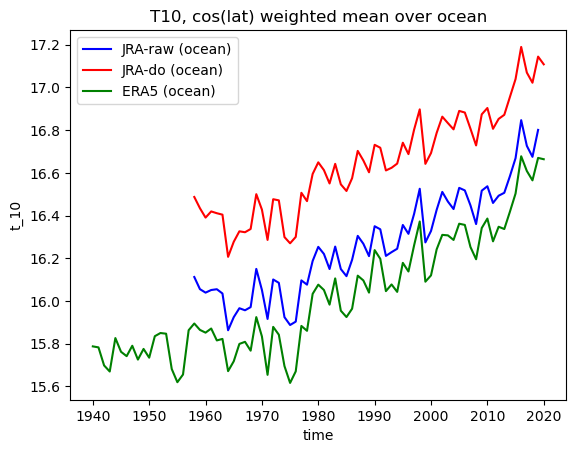

In [16]:
(temp_ocean_means1-273.15).plot(c = 'b', label = 'JRA-raw (ocean)')
(temp_ocean_means2-273.15).plot(c = 'r', label = 'JRA-do (ocean)')
(temp_ocean_means3-273.15).plot(c = 'g', label = 'ERA5 (ocean)')
plt.title('T10, cos(lat) weighted mean over ocean')
plt.legend()

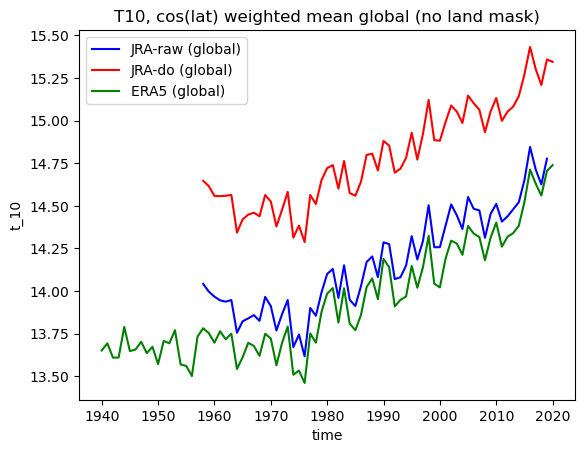

In [17]:
(temp_means1-273.15).plot(c = 'b', label = 'JRA-raw (global)')
(temp_means2-273.15).plot(c = 'r', label = 'JRA-do (global)')
(temp_means3-273.15).plot(c = 'g', label = 'ERA5 (global)')
plt.title('T10, cos(lat) weighted mean global (no land mask)')
plt.legend()

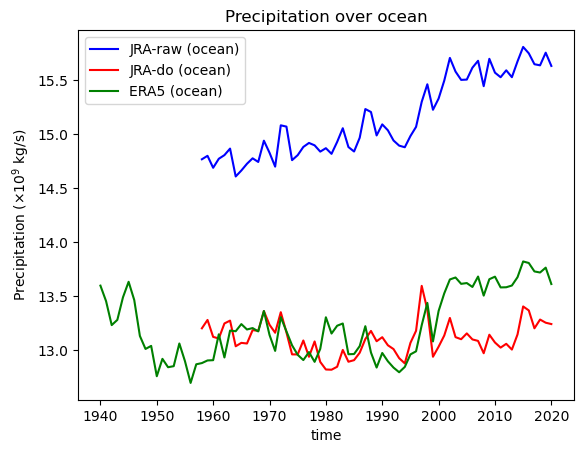

In [21]:
(prec_ocean_means1/1e9).plot(c = 'b', label = 'JRA-raw (ocean)')
(prec_ocean_means2/1e9).plot(c = 'r', label = 'JRA-do (ocean)')
(prec_ocean_means3/1e9).plot(c = 'g', label = 'ERA5 (ocean)')
plt.title('Precipitation over ocean')
plt.ylabel(r'Precipitation ($\times 10^9$ kg/s)')
plt.legend()

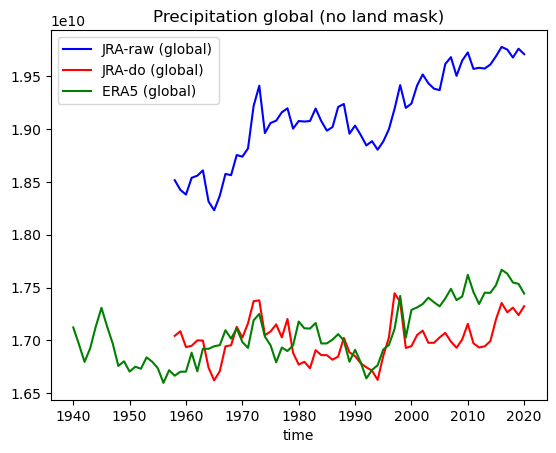

In [19]:
(prec_means1/1e9).plot(c = 'b', label = 'JRA-raw (global)')
(prec_means2/1e9).plot(c = 'r', label = 'JRA-do (global)')
(prec_means3/1e9).plot(c = 'g', label = 'ERA5 (global)')
plt.title('Precipitation global (no land mask)')
plt.ylabel(r'Precipitation ($\times 10^9$ kg/s)')
plt.legend()